In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pandas.plotting import scatter_matrix
from mpl_toolkits.mplot3d import Axes3D  
import numpy.linalg as la

In [3]:
Y = np.array([22,13,33,38,23,47,29,38,41,32,20,13,47,
              38,44,29,38,37,14,34,25,27,25,43,34], dtype=float)

X2 = np.array([139,132,144,142,142,142,138,139,144,134,135,137,146,
               146,144,147,144,149,131,144,132,132,127,154,147], dtype=float)

X1 = np.array([2371,2226,2731,3351,2289,3449,3114,3342,2842,2625,2121,2219,3463,
               3290,3103,2122,2791,3209,2287,2848,2690,2933,2671,2988,2829], dtype=float)

df = pd.DataFrame({
    "Comisiones_Y": Y,
    "Millas_X1": X1,
    "Llamadas_X2": X2
})

print(df.head())

   Comisiones_Y  Millas_X1  Llamadas_X2
0          22.0     2371.0        139.0
1          13.0     2226.0        132.0
2          33.0     2731.0        144.0
3          38.0     3351.0        142.0
4          23.0     2289.0        142.0


In [5]:
r_y1 = np.corrcoef(Y, X1)[0,1]  
r_y2 = np.corrcoef(Y, X2)[0,1]  
r_12 = np.corrcoef(X1, X2)[0,1] 

print("\nCorrelaciones simples:")
print("r(Y, X1) =", round(r_y1, 4))
print("r(Y, X2) =", round(r_y2, 4))
print("r(X1, X2) =", round(r_12, 4))


Correlaciones simples:
r(Y, X1) = 0.8323
r(Y, X2) = 0.6797
r(X1, X2) = 0.4011


In [7]:
R_formula = np.sqrt((r_y1**2 + r_y2**2 - 2*r_y1*r_y2*r_12) / (1 - r_12**2))
print("\nCorrelación múltiple (fórmula): R =", round(R_formula, 4))


Correlación múltiple (fórmula): R = 0.9139


In [9]:
X = np.column_stack([np.ones(len(Y)), X1, X2])
beta = la.lstsq(X, Y, rcond=None)[0]

Y_hat = X @ beta
SS_res = np.sum((Y - Y_hat)**2)
SS_tot = np.sum((Y - np.mean(Y))**2)
R2 = 1 - (SS_res / SS_tot)
R_reg = np.sqrt(R2)

print("\nRegresión múltiple:")
print("b0 =", round(beta[0], 4), "b1 =", round(beta[1], 6), "b2 =", round(beta[2], 6))
print("R^2 =", round(R2, 4))
print("R  =", round(R_reg, 4), " (debe coincidir con la fórmula)")


Regresión múltiple:
b0 = -101.3144 b1 = 0.015689 b2 = 0.632333
R^2 = 0.8353
R  = 0.9139  (debe coincidir con la fórmula)


<Figure size 800x800 with 0 Axes>

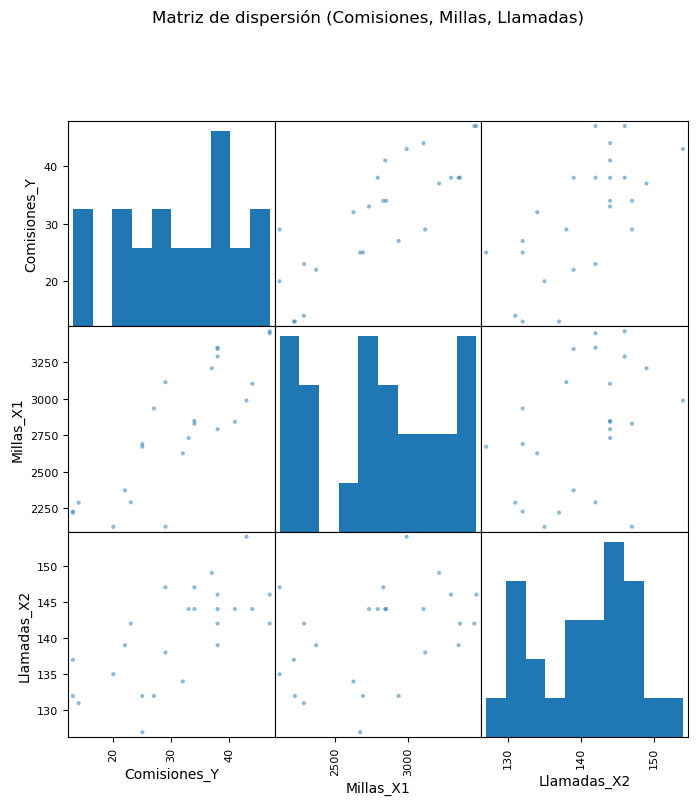

In [11]:
plt.figure(figsize=(8, 8))
scatter_matrix(df, figsize=(8, 8), diagonal='hist')
plt.suptitle("Matriz de dispersión (Comisiones, Millas, Llamadas)", y=1.02)
plt.show()

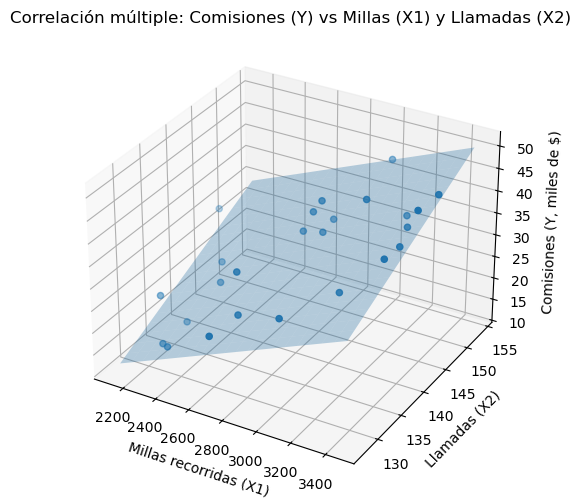

In [13]:
fig = plt.figure(figsize=(9, 6))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(X1, X2, Y)

# Plano de regresión
x1_grid = np.linspace(X1.min(), X1.max(), 20)
x2_grid = np.linspace(X2.min(), X2.max(), 20)
X1g, X2g = np.meshgrid(x1_grid, x2_grid)
Yg = beta[0] + beta[1]*X1g + beta[2]*X2g

ax.plot_surface(X1g, X2g, Yg, alpha=0.3)

ax.set_title("Correlación múltiple: Comisiones (Y) vs Millas (X1) y Llamadas (X2)")
ax.set_xlabel("Millas recorridas (X1)")
ax.set_ylabel("Llamadas (X2)")
ax.set_zlabel("Comisiones (Y, miles de $)")

plt.show()

In [15]:
print("\nMatriz de correlación (Pearson):")
print(df.corr())


Matriz de correlación (Pearson):
              Comisiones_Y  Millas_X1  Llamadas_X2
Comisiones_Y      1.000000   0.832271     0.679716
Millas_X1         0.832271   1.000000     0.401075
Llamadas_X2       0.679716   0.401075     1.000000
